# Hidden Markov Model (HMM)

HMM is a statistical model used to describe a Markov process with unobserved (hidden) states.

### Model Description
It is defined by the following 5 core elements:

1. **Hidden States**: The underlying states that actually exist but can not be observed directly.
    $$ S={s_1, s_2, ..., s_N} \text{,} \quad \text{with } N \text{ possible hidden states}$$
<br>

2. **Observations**: The data or outcomes that we can actually see and measure.
    $$ V={v_1, v_2, ..., v_M} \text{,} \quad \text{with } M \text{ possible observations}$$
<br>

3. **State Transition Probability Matrix**: Defines the probability of moving from one hidden state to another.

    $$ A_{N \times N}= [a_{i,j}]= \begin{bmatrix}
    a_{1,1} & a_{1,2} & \dots & a_{1,N} \\
    a_{2,1} & a_{2,2} & \dots & a_{2,N} \\
    \vdots & \vdots &  & \vdots \\
    a_{N,1} & a_{N,2} & \dots & a_{N,N} \\
    \end{bmatrix} $$
    
    <br>
    

    - $\forall i = 1, \dots, N$ and $\forall j = 1, \dots, N$

    - $a_{i,j} = P(q_{t+1} = s_j | q_t = s_i)$ is the probability of transitioning from state $s_i$ to state $s_j$, where $q_t$ is the hidden state at time $t$.

    - The sum of each row must equal 1:  $\sum_{i} a_{i,j} = 1.0$.
    
<br>

4. **Observation Emission Probability Matrix**: Defines the probability that a specific hidden state "emits" or produces a specific observation.

    $$ B_{N \times M} = [b_j(v_k)] = \begin{bmatrix}
        [ b_{1}(v_1) & b_{1}(v_2) & \dots & b_{1}(v_{M}) ] \\
        [ b_{2}(v_1) & b_{2}(v_2) & \dots & b_{2}(v_{M}) ] \\
        \vdots & \vdots &  & \vdots \\
        [ b_{N}(v_1) & b_{N}(v_2) & \dots & b_{N}(v_{M}) ] \\
        \end{bmatrix}
    $$
    <br>
    
    - $\forall j = 1, \dots, N$ and $\forall v_k \in V \text{, where } k = 1, \dots, M$

    - $b_{j}(k) = P( O_t = v_k | q_t = s_j)$  is the probability of observing $v_{k}$ given that the system is currently in hidden state $s_j$, where $O_t$ is the observation at time $t$ and $q_t$ is the hidden state at time $t$.
    
    - The sum of each row must equal 1: $\sum_{k} b_j(v_k) = 1$.

<br>

5. **Initial State Probability Distribution**: The probability of starting in each hidden state at time $t = 1$.

    $$ \pi_i = P(q_1 = s_i)  $$





### The Fundamental Assumptions of HMM
To make calculations mathematically feasible, and HMM relies on two strict assumptions:

1. Current state depends only on the previous state

    - The hidden state at time $t$ depends **exclusively** on the hidden state at time $t-1$. It is completely independent od any earlier history.

    - $P(q_{t+1} | q_t, q_{t-1}, ... q_0, o_t, o_{t-1}, ...) = P(q_{t+1} | q_t)$ 


2. Observation depends only on the state at the same moment.

    - The observation generated at time $t$ depends exclusively on the current hidden state at time $t$.

    - $P(o_{t+1} | q_{t+1}, q_t, ... q_0, o_{t+1}, o_t, ...) = P(o_{t+1} | q_{t+1})$


### Example: CpG Island vs. Background Sequence

There are two hidden stats: whether it is located on CpG island or background region.
$$ S = [ \text{'BG'}, \text{'CG'}] $$

The system tends to stay in its current state. The state transition probability matrix is defined as below.
$$ A = \begin{bmatrix}
0.95 & 0.05  \\
0.15 & 0.85  \\
\end{bmatrix} $$

The observation emission probability matrix:
$$ B = \begin{bmatrix}
0.25 & 0.25 & 0.25 & 0.25  \\
0.10 & 0.40 & 0.40 & 0.10  \\
\end{bmatrix} $$

The initial state probability distribution:
$$ \pi = [0.90, 0.10 ] $$


<br><br>
⚠️ **NOTE**: Unlike the previous Markov chain, where the next base was determined by the prior base, this model's base probability distribution depends exclusively on the states. Consequently, it captures states transition frequency within two continuous hidden states rather than sequential patterns (bases).


In [32]:
import numpy as np
from numpy.typing import NDArray
from hmmlearn import hmm
from sklearn.metrics import confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def hmm_generator(
    seq_length: int,
    states: list[str],
    bases: list[str],
    transition: NDArray[np.float64],
    emission: NDArray[np.float64],
    pi: NDArray[np.float64],
) -> tuple[list, str]:
    
    hidden_path = []
    observed_sequence = ""

    map_states = {state: idx for idx, state in enumerate(states)}

    # Initialize hidden state
    current_hidden = np.random.choice(states, p=pi)

    for t in range(seq_length):
        hidden_path.append(current_hidden)
        cur_hidden_idx = map_states.get(current_hidden)

        # Get emission prob according to current hidden state
        emission_prob = emission[cur_hidden_idx]
        # Get current emission observation 
        cur_base = np.random.choice(bases, p=emission_prob)
        observed_sequence += cur_base

        # Get next hidden states according to current hidden states
        transition_prob = transition[cur_hidden_idx]
        current_hidden = np.random.choice(states, p=transition_prob)

    return (hidden_path, observed_sequence)


In [3]:
state_size = ["BG", "CG"]
bases = ["A", "C", "G", "T"]

transition = np.array([[0.95, 0.05], [0.15, 0.85]])
emission = np.array([[0.25, 0.25, 0.25, 0.25], [0.10, 0.40, 0.40, 0.10]])
pi = np.array([0.90, 0.10])

hidden_path, observed_sequence = hmm_generator(100, state_size, bases, transition, emission, pi)


print(f"hidden:   {','.join(hidden_path)}")
print(f"sequence: {'_,'.join(observed_sequence)}")

hidden:   BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,CG,CG,CG,CG,CG,CG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG
sequence: G_,A_,G_,A_,A_,G_,T_,A_,A_,G_,T_,C_,T_,G_,T_,C_,G_,A_,A_,A_,A_,G_,A_,T_,G_,G_,G_,T_,A_,T_,A_,T_,A_,G_,A_,C_,T_,C_,G_,A_,C_,C_,A_,T_,A_,G_,C_,C_,C_,A_,A_,C_,T_,G_,T_,T_,C_,T_,C_,G_,T_,T_,C_,C_,T_,C_,G_,C_,T_,G_,A_,G_,C_,G_,C_,C_,G_,A_,C_,T_,A_,C_,G_,G_,G_,C_,T_,G_,T_,G_,G_,C_,G_,A_,C_,A_,G_,G_,T_,G


## Viterbi Algorithm

The Viterbi Algorithm is a **dynamic programming** algorithm used to find the most likely sequence of hidden states (called the Viterbi path) that results in a sequence of observed events, given a Hidden Markov Model (HMM). To construct the model, we first assume that:
- $o_t$ is the observation at time $t$.
- $\delta_{t}(i)$ is the maximum probability that the HMM is in hidden state $s_i$ at time $t$.
- $\delta_{t-1}(i)$ is the probability of the best path up to the previous step ending in state $s_i$.
- $\psi_t(i)$ is a backpointer matrix used to log which previous state $s_i$ yielded the maximum probability.

#### Step 1: Initialization
For $t=1$ and $ 1 \leq i \leq N $,
$$ \delta_{1}(i) = \pi_{i} \cdot b_{i}(o_{1}) 
\quad \text{ and } \quad
\psi_t(i) = 0 $$


#### Step 2: Recursive steps 
For $t=2, 3, \dots,T$ and $ 1 \leq j \leq N $,
$$ \delta_{t}(j) = \max_{1 \leq i \leq N} \big[ \delta_{t-1}(i) \cdot a_{i,j} \big] \cdot b_{j}(o_t) 
\quad \text{ and } \quad
\psi_t(j) = \argmax_{1 \leq i \leq N} \big[ \delta_{t-1}(i) \cdot a_{i,j} \big] $$


#### Step 3: Termination
For $t=T$, identify the highest total probability across all terminal states at the final sequence position:

$$ P^{*} = \max_{1 \leq i \leq N} \psi_T(i) 
\quad \text{ and } \quad
q^{*}_{T} = \argmax_{1 \leq i \leq N} \psi_T(i) $$

#### Step 4: Path Backtracking
From $t = T-1$ down to 1, trace backward through the saved $\psi$ matrix to reconstruct the sequence of hidden states:
$$ q^{*}_{t} = \psi_{t+1}(q^{*}_{t+1}) $$




### Numerical Stability in Practice: Log-Space Viterbi

In practical computer systems processing long DNA sequences, multiplying continuous probability values yields numeric underflow errors where values truncate directly to zero.To solve this, equations are transformed using **natural logarithms**, turning raw multiplications into stable additions:

$$\log \delta_{t}(j) = \max _{i} \left[ \log \delta_{t-1}(i) + \log a_{i,j} \right] + 
\log b_{j}(t) $$

### Excercise 1: Implement Log-Space Viterbi Algorithm

In [4]:
def log_viterbi(obs: NDArray, state_size: int, pi: NDArray[np.float64], trans: NDArray[np.float64], emis: NDArray[np.float64]):
    """
    Computes the most likely sequence of hidden states using log-space Viterbi.

    Args:
        - obs (NDArray): A list of observation indices, shaps (T,)
        - states (int): The number of states (N)
        - pi (NDArray): Initial state probability distribution, shape (N,)
        - trans (NDArray): Transition probability matrix, shape (N, N)
        - emis (NDArray): Emission probability matrix, shape (N, M)

    Return:
        - best_path (NDArray)

    """

    T = len(obs)
    N = state_size

    # 1. Convert all probabilites to log-space (use small epsilon to avoid log(0) error)
    epsilon = 1e-100
    log_pi = np.log(pi + epsilon)
    log_trans = np.log(trans + epsilon)
    log_emis = np.log(emis + epsilon)

    # 2. Create Viterbi matrix (delta) and Backpointer tracking matrix (psi)
    delta = np.zeros((N,T)) # The maximum probabilites that the given obervation o_t is from hidden state i, i=1, ..., N
    psi = np.zeros((N,T), dtype=int) # Log which previous states had the maximum probability.

    # 3. Computing best path
    # 3-1 Initialization
    delta[:, 0] = log_pi + log_emis[:, obs[0]]

    # 3-2 Recursion
    for t in range(1, T):
        for j in range(N):
            # max_i [ delta_i(t-1) + log_trans(i -> j) ] + log_emit(j -> obs_t)
            trans_scores = delta[:, t-1] + log_trans[:, j]
            psi[j, t] = np.argmax(trans_scores)
            delta[j, t] = np.max(trans_scores) + log_emis[j, obs[t]]
    
    # 4. Traceback 
    best_path = np.zeros(T, dtype=int)

    best_path[-1] = np.argmax(delta[:, -1])
    for t in range(T-2, -1, -1):
        best_path[t] = psi[best_path[t+1], t+1]
    
    return best_path, delta, psi
            

### Excersice 2: Using `hmmlearn`

The `hmmlearn` [library](https://github.com/hmmlearn/hmmlearn) is implemented in Cython for high performance and utilizes log-space arithmetic to prevent numerical underflow. The `.predict()` method of the `hmmlearn.hmm.CategoricalHMM` model natively uses the Viterbi algorithm to decode hidden states. 


In [13]:
def viterbi_hmmlearn(obs: NDArray, state_size: int, pi: NDArray, trans: NDArray, emis: NDArray):
    # model = hmm.MultinomialHMM(n_components=state_size)
    model = hmm.CategoricalHMM(n_components=state_size)

    model.startprob_ = pi
    model.transmat_ = trans
    model.emissionprob_ = emis
    obs = obs.reshape(-1, 1)

    hidden_states = model.predict(obs)
    # log_prob, hidden_states_decode = model.decode(obs)

    return hidden_states

In [39]:
states = ["BG", "CG"]
bases = ["A", "C", "G", "T"]
transition = np.array([[0.85, 0.15], [0.15, 0.85]])
emission = np.array([[0.25, 0.25, 0.25, 0.25], [0.10, 0.40, 0.40, 0.10]])
pi = np.array([0.50, 0.50])

# Generate observations
hidden_path, observed_sequence = hmm_generator(500, states, bases, transition, emission, pi)
base_map = {base: idx for idx, base in enumerate(bases)}
obs = np.array([ base_map.get(b) for b in observed_sequence])

# Conduct manual version
best_path, delta, psi = log_viterbi(obs, 2, pi, transition, emission)

# Conduct hmmlearn version
hmm_best_path = viterbi_hmmlearn(obs, 2, pi, transition, emission)



In [40]:
print(f"Ground:    {','.join(hidden_path)}")
print(f"manual:    {','.join([states[i] for i in best_path])}")
print(f"hmmlearn:  {','.join([states[i] for i in hmm_best_path])}")

state_map = { state: idx for idx, state in enumerate(states)}
backgroud = np.array([ state_map.get(b) for b in hidden_path ])


Ground:    BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,CG,CG,CG,CG,CG,CG,CG,BG,BG,BG,BG,BG,BG,BG,BG,BG,CG,CG,CG,CG,CG,BG,BG,CG,CG,CG,CG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,CG,CG,CG,CG,CG,CG,BG,BG,BG,BG,BG,CG,CG,BG,BG,CG,BG,BG,CG,CG,CG,BG,BG,CG,CG,CG,CG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,BG,BG,BG,BG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,BG,BG,CG,CG,CG,CG,CG,CG,CG,BG,BG,BG,BG,BG,BG,BG,BG,BG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,BG,BG,BG,BG,BG,CG,CG,CG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,BG,CG,CG,CG,CG,CG,CG,CG,CG,BG,BG,BG,BG,CG,BG,CG,CG,CG,CG,CG,CG,BG,BG,BG,BG,BG,BG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,CG,CG,CG,CG,BG,BG,BG,CG,CG,BG,BG,BG,BG,BG,CG,CG,CG,BG,BG,BG,BG,BG,CG,CG,CG,CG,CG,CG,CG,BG,CG,CG,CG,BG,BG,CG,CG,CG,BG,BG,BG,BG,BG,CG,CG,CG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,CG,CG

### Evaluate Viterbi Algorithm Prediction Result

#### Method 1: Parallel Step Lines

This method plots the true path and predicted path as two distinct horizontal step lines. It makes it very easy to spot exactly where the Viterbi algorithm made a mistake.

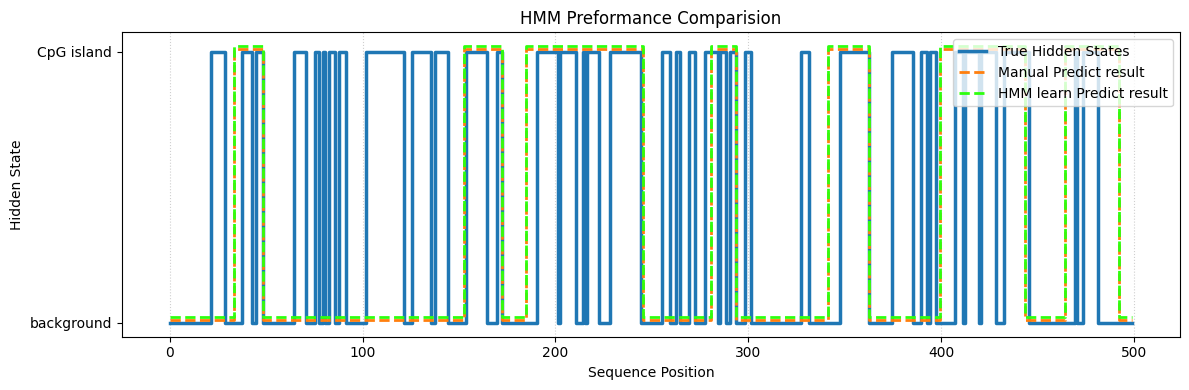

In [41]:
time_steps = np.arange(len(hidden_path))
plt.figure(figsize=(12,4))

plt.step(time_steps, backgroud, label="True Hidden States", color="#1f77b4", linewidth=2.5, where='mid')
plt.step(time_steps, best_path + 0.01, label="Manual Predict result", color="#ff7f0e", linewidth=2, linestyle="--", where='mid')
plt.step(time_steps, hmm_best_path + 0.02, label="HMM learn Predict result", color="#2eff0e", linewidth=2, linestyle="--", where='mid')

plt.yticks([0,1], ['background', 'CpG island'])
plt.xlabel("Sequence Position")
plt.ylabel("Hidden State")
plt.title("HMM Preformance Comparision")
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()


#### Method 2: Dual-Track Color Blocks 

If your DNA sequence is hundreds of base pairs long, lines become unreadable. Drawing solid colored blocks (like a genome browser track) is the standard approach in bioinformatics.

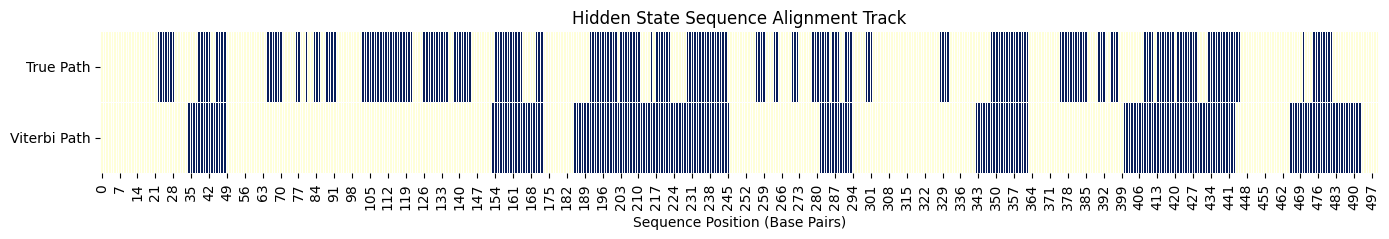

In [42]:
heatmap_data = np.vstack([backgroud, best_path])

plt.figure(figsize=(14, 2.5))

# Use Seaborn heatmap without colorbar, using distinct colors for states
sns.heatmap(heatmap_data, cmap="YlGnBu", cbar=False, linewidths=0.5, linecolor="white")

# Adjust ticks and labels
plt.yticks([0.5, 1.5], ['True Path', 'Viterbi Path'], rotation=0)
plt.xlabel("Sequence Position (Base Pairs)")
plt.title("Hidden State Sequence Alignment Track")

plt.tight_layout()
plt.show()

#### Method 3: Confusion Matrix
While tracks show where errors happen, a confusion matrix tells you what kind of mistakes your Viterbi algorithm is making overall (e.g., misclassifying State A as State B).

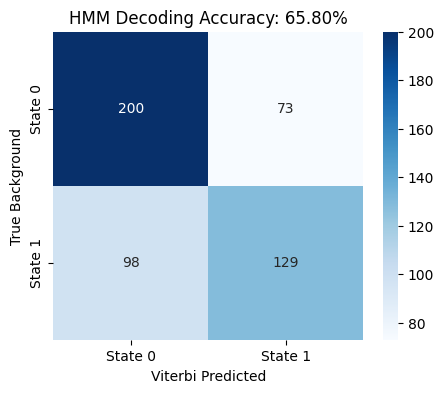

In [43]:
# Calculate summary metrics
acc = accuracy_score(backgroud, best_path)
cm = confusion_matrix(backgroud, best_path)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['State 0', 'State 1'], 
            yticklabels=['State 0', 'State 1'])

plt.xlabel('Viterbi Predicted')
plt.ylabel('True Background')
plt.title(f'HMM Decoding Accuracy: {acc:.2%}')
plt.show()

### Conclusion

